In [1]:
import numpy as np
import ray
ray.init(num_cpus=16)
import wannierberri as wberri
from wannierberri.system import System_PythTB
from hall_ps.hall_positional_shift import HallPositionalShift, Data_K_pos_shift

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-22 16:24:58,090	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-22 16:25:00,979	INFO worker.py:1918 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [2]:
wberri.welcome()


.::    .   .::: .:::::::.  :::.    :::.:::.    :::. :::.,::::::  :::::::..       :::::::.  .,::::::  :::::::..   :::::::..   :::
';;,  ;;  ;;;' '  ;;`;;  ` `;;;;,  `;;;`;;;;,  `;;; ;;;;;;;''''  ;;;;``;;;;       ;;;'';;' ;;;;''''  ;;;;``;;;;  ;;;;``;;;;  ;;;
 '[[, [[, [['    ,[[ '[[,    [[[[[. '[[  [[[[[. '[[ [[[ [[cccc    [[[,/[[['       [[[__[[\. [[cccc    [[[,/[[['   [[[,/[[['  [[[
   Y$c$$$c$P    c$$$cc$$$c   $$$ "Y$c$$  $$$ "Y$c$$ $$$ $$""""    $$$$$$c         $$""""Y$$ $$""""    $$$$$$c     $$$$$$c    $$$
    "88"888      888   888,  888    Y88  888    Y88 888 888oo,__  888b "88bo,    _88o,,od8P 888oo,__  888b "88bo, 888b "88bo,888
     "M "M"      YMM   ""`   MMM     YM  MMM     YM MMM """"YUMMM MMMM   "W"     ""YUMMMP"  """"YUMMM MMMM   "W"  MMMM   "W" MMM

Version: 26.4.6.dev10+g99ce3f530.d20260415


   HTTP://WANNIER-BERRI.ORG  

Checking dependencies …
irrep : 2.6.3
spglib : 2.7.0
numpy : 2.4.2
scipy : 1.15.2
spgrep : 0.5.0
numba : 0.64.0
pyfftw : 0.15.1
seekpath : 2.2.1
mat

{'irrep': '2.6.3',
 'spglib': '2.7.0',
 'numpy': '2.4.2',
 'scipy': '1.15.2',
 'spgrep': '0.5.0',
 'numba': '0.64.0',
 'pyfftw': '0.15.1',
 'seekpath': '2.2.1',
 'matplotlib': '3.10.8',
 'sympy': '1.14.0',
 'fortio': '0.4',
 'gpaw': '25.1.0',
 'ase': '3.27.0',
 'pythtb': '2.0.0',
 'xmltodict': '1.0.2'}

# WannierBerri PythTB

In [3]:
from ferroaxial_model import model_ferroaxial_pythtb, visualise

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (25, 2, 2)
Real-space lattice:
 [[ 1.50000000e+00 -8.66025404e-01  0.00000000e+00]
 [-1.94289029e-16  1.73205081e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Number of wannier functions: 2
Number of R points: 25
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully
Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (25, 2, 2)
Real-space lattice:
 [[ 1.50000000e+00 -8.66025404e-01  0.00000000e+00]
 [-1.94289029e-16  1.73205081e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Number of wannier functions: 2
Number of R points: 25
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


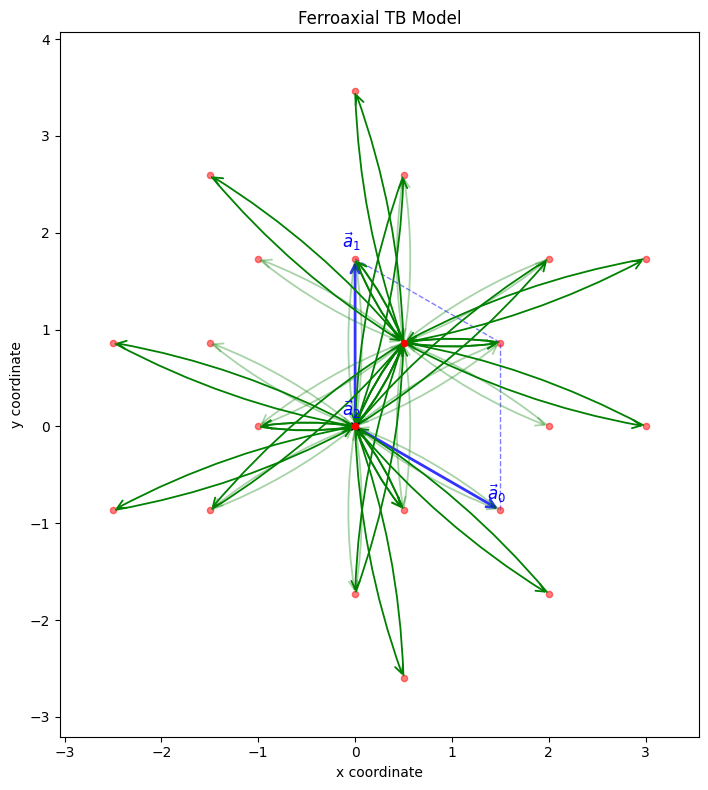

In [4]:
parameters1 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.25, a=1.0, c=1.0, rot_deg=-30)
model1 = model_ferroaxial_pythtb(**parameters1)
visualise(model1, title="Ferroaxial TB Model", filename="visualize_model_ferroaxial.pdf")
system_nosym = System_PythTB(model1)
system_sym = System_PythTB(model1)
system_sym.set_pointgroup(symmetry_gen=["C3z", "TimeReversal"])

# Positional Shift

In [5]:
import os


tetra = False
Efermi = np.linspace(-8, +8, 1601)
from wannierberri.smoother import FermiDiracSmoother
smoother = FermiDiracSmoother(T_Kelvin=1000, E=Efermi)

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)
os.makedirs('./output', exist_ok=True)

system = system_sym
suffix = "nosym-smoothed"
grid = wberri.Grid(system, NKdiv=[8,8,8], NKFFT=[8,8,8])
result_run = wberri.run(system,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=0,
            fout_name=f'./output/ferroaxial-tb-TR-{suffix}',
            restart=False,
            use_irred_kpt=False,
            symmetrize=False,
            data_k_class=Data_K_pos_shift
            )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x7e5547b9b920>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x7e5548302450>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x7e5547b9b920>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x7e5548302450>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[8 8 8], NKFFT=[8 8 8], NKtot=[64 64 64]
generating K_list
Done in 0.001352548599243164 s 
K_list contains 512 Irreducible points(100.0%) out of initial 8x8x8=512 grid
Done, sum of weigh

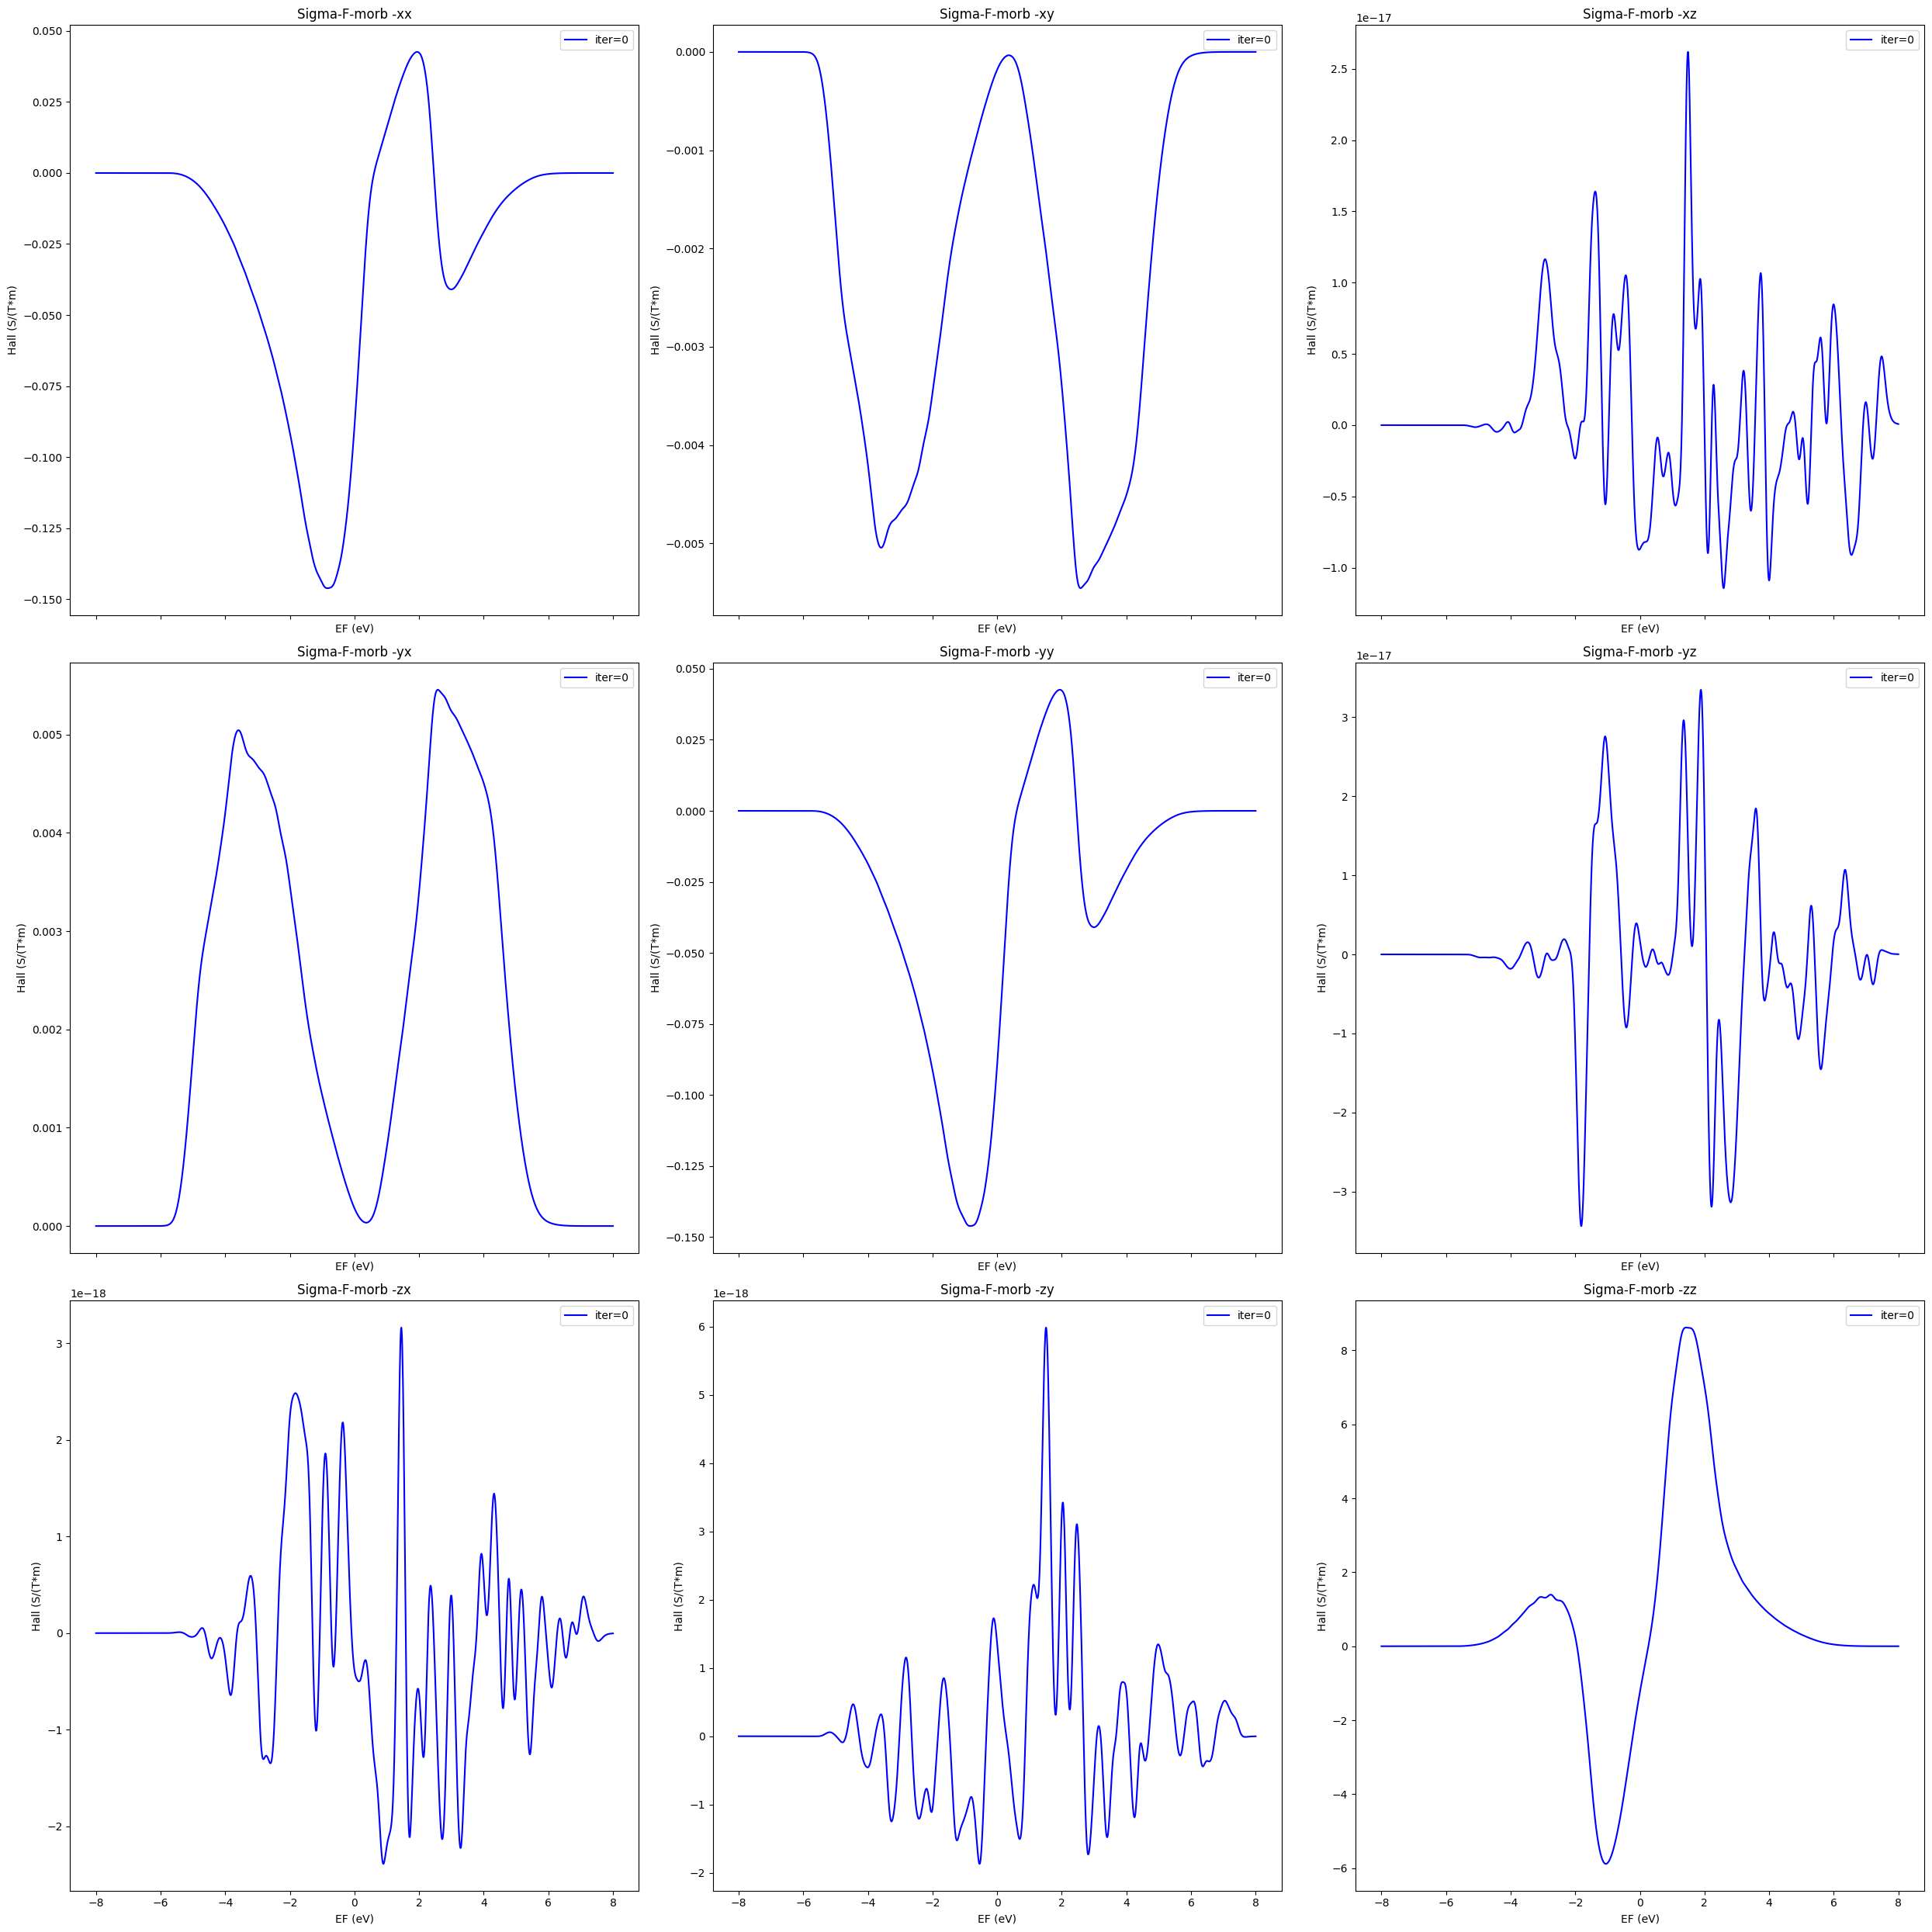

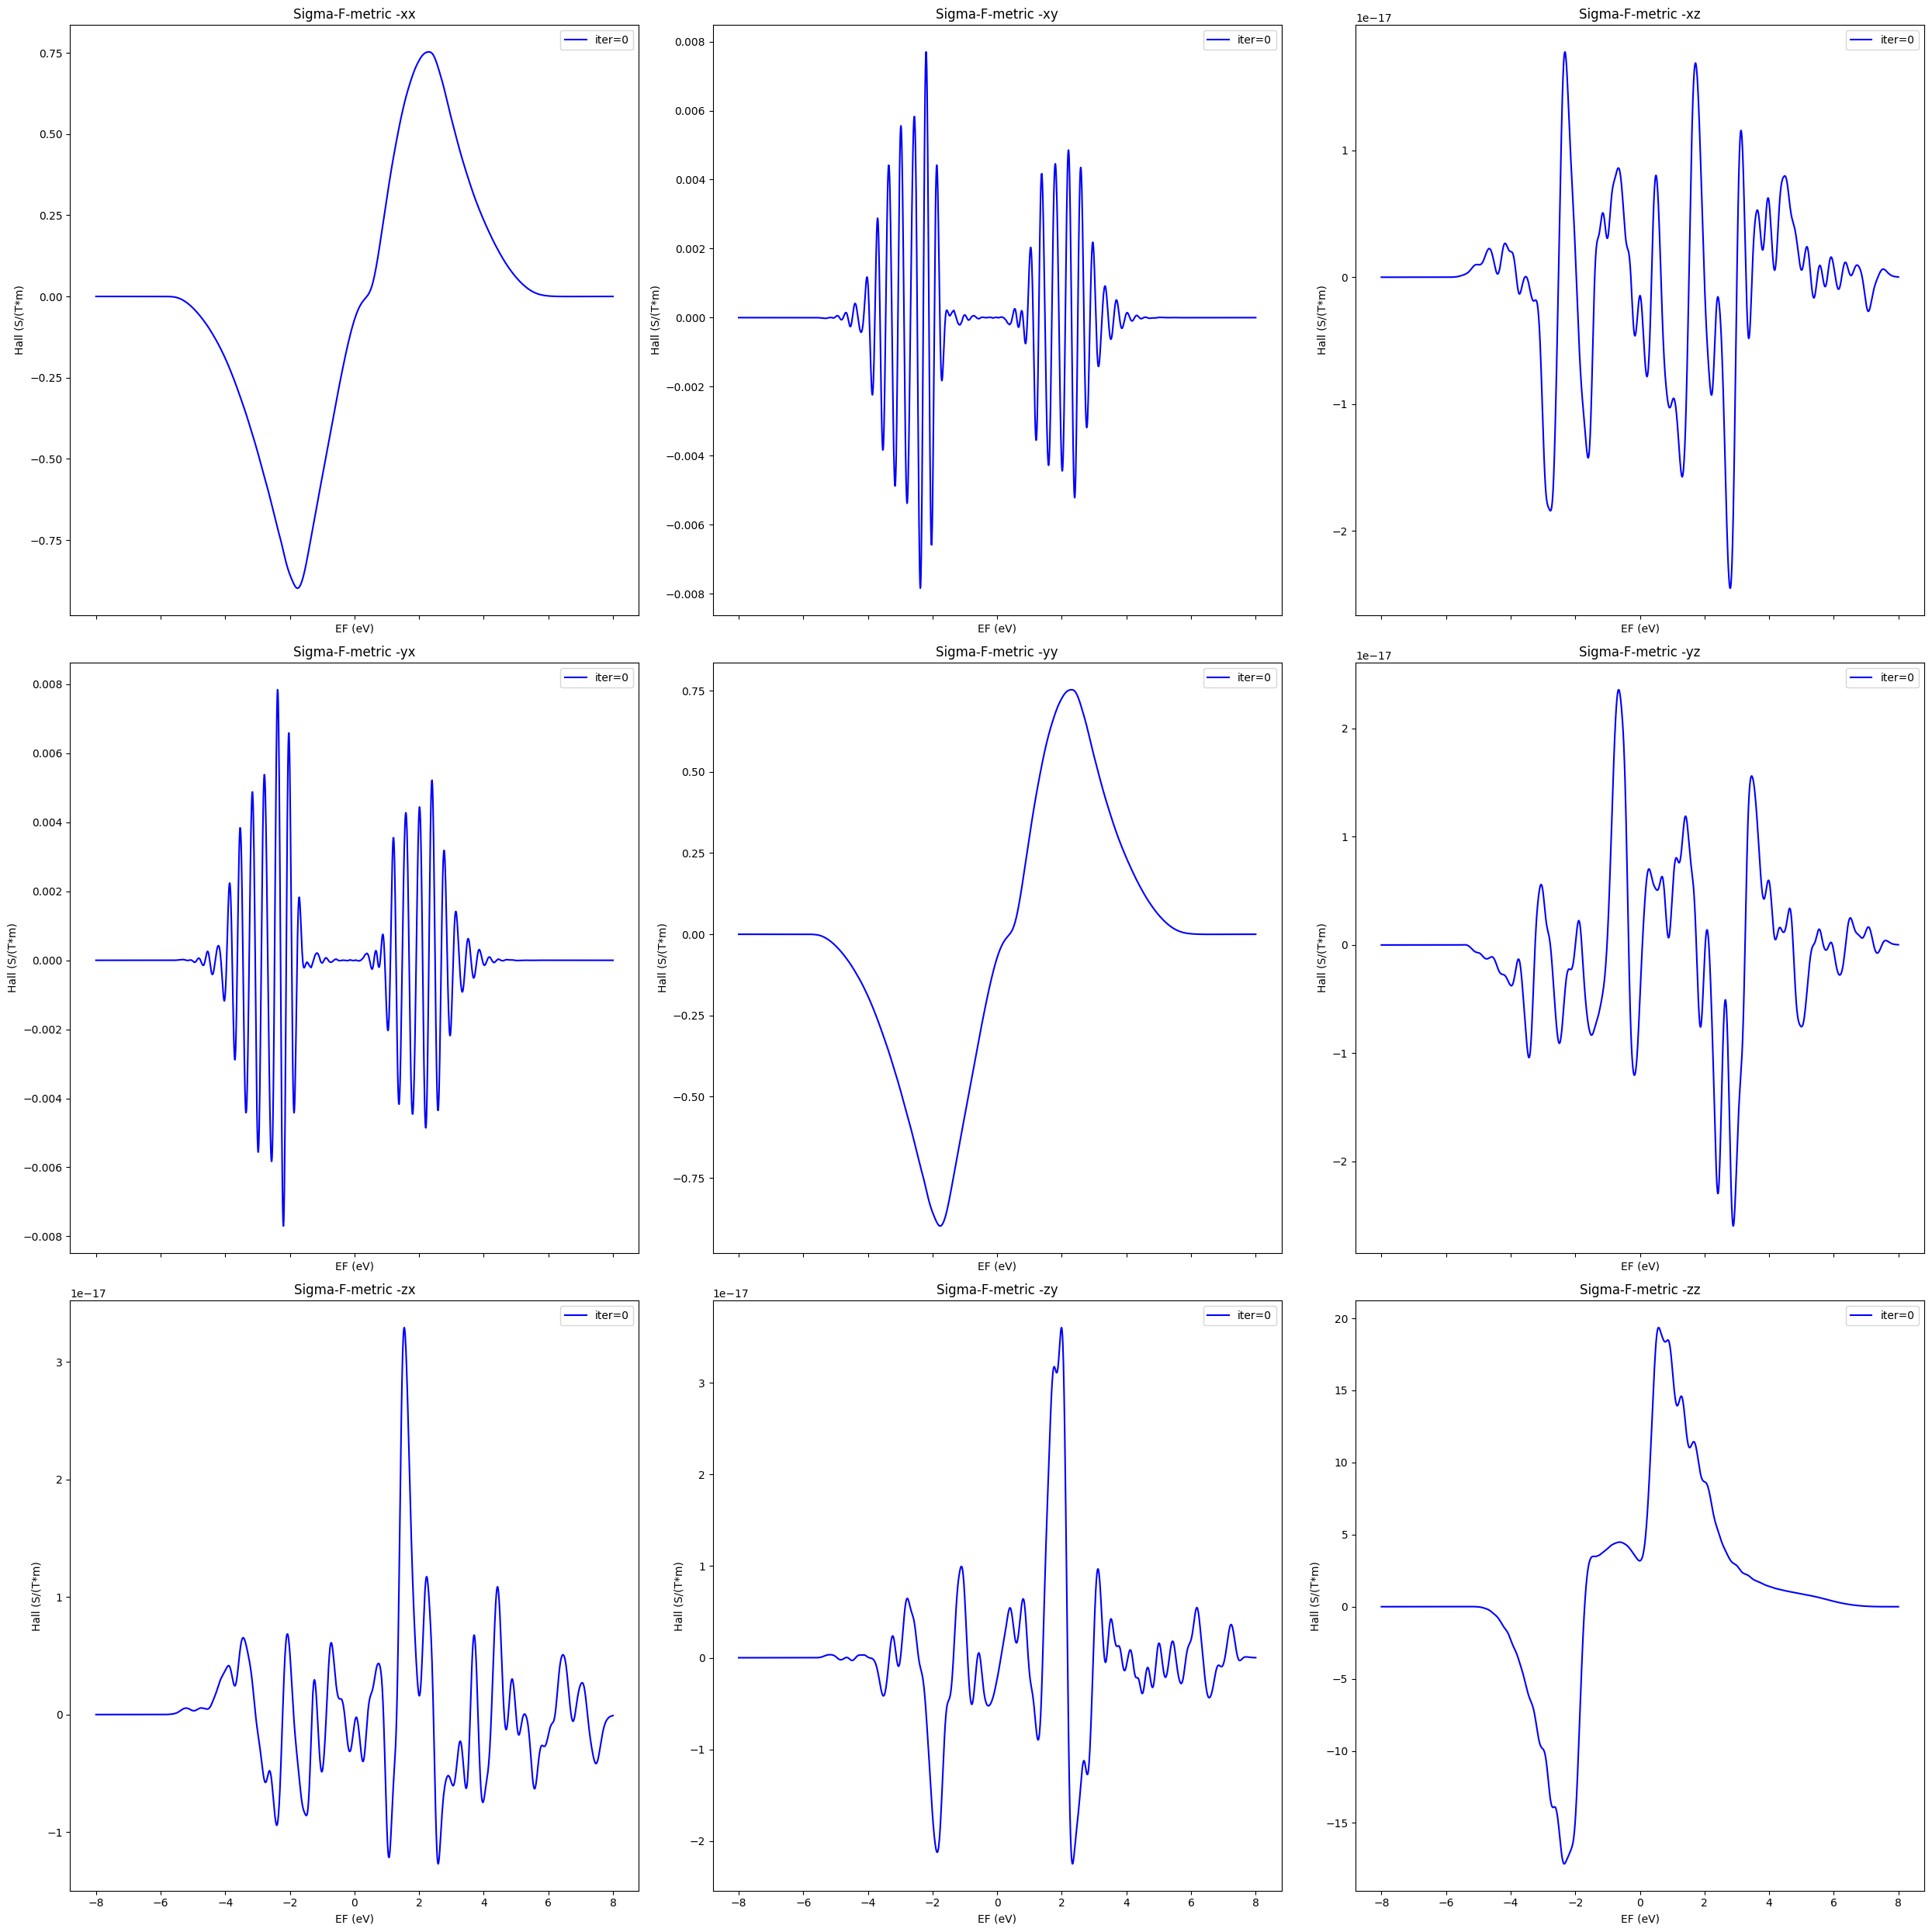

In [6]:
from matplotlib import pyplot as plt
import numpy as np

def plot_integrated(ax, seedname, iter_start, iter_end, iter_step, suffix="", component=(0,1), smoother=None):
    for i in range(iter_start, iter_end+1, iter_step):
        res_ps_morb =  np.load(f"output/{seedname}-hall_positional_shift_{suffix}_iter-{i:04d}.npz")
        Efermi = res_ps_morb['Energies_0']
        alpha = (i-iter_start)/(iter_end-iter_start)
        color = (0, alpha, 1-alpha)
        data = res_ps_morb["data"][:,*component]
        if smoother is not None:
            data = smoother(data)
        ax.plot(Efermi , data, label=f"iter={i}", color=color)
    ax.set_title(f"{seedname} convergence")
    ax.set_xlabel("EF (eV)")
    ax.set_ylabel("Hall (S/(T*cm)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{seedname}_convergence.png", dpi=300)


smoother = FermiDiracSmoother(T_Kelvin=1000, E=Efermi)


for term in ["morb", "metric"]:
    fig, axes = plt.subplots(3, 3, sharey=False, sharex=True, figsize=(25, 25))
    for i in range(3):
        for j in range(3):
            ax = axes[i,j]
            plot_integrated(ax, seedname="ferroaxial-tb-TR-nosym-smoothed", iter_start=0, iter_end=1, iter_step=2, suffix=term, component=(i,j), smoother=smoother)
            ax.set_title(f"Sigma-F-{term} -{"xyz"[i]}{"xyz"[j]}")
            ax.set_xlabel("EF (eV)")
            ax.set_ylabel("Hall (S/(T*m)")
    plt.tight_layout()



In [7]:
%ls output/*tetra*

ls: cannot access 'output/*tetra*': No such file or directory
